In [192]:
import pandas as pd
import seaborn as sns
import matplotlib as mtb
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [193]:
df = pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [195]:
# checking the total number of not available informations
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

- HANDLING MISSING VALUES


In [196]:
# SEPERATING THE CATEGORICAL DATA AND NUMERICAL DATA FOR EACH OTHER

# select_dtypes() is used to select the particular columns on the basis of a particular data type

categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [197]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [198]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [199]:
# FILLING THE MISSING VALUE USING THE SIMPLE_IMPUTER , like this
from sklearn.impute import SimpleImputer

# ----------------------------------------------------------------------------------------------------

# now to fill the values i will be needed to create the imputer , and we will be needed 2 types of them
# bcz we are going to use two different stratigies.

# 1. first for the numerical data , we are filling it with the mean
num_imputer = SimpleImputer(strategy="mean")

# saving in those that were not available
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# ----------------------------------------------------------------------------------------------------

# 2. second for the categorical data , we are filling it with the mode
cat_imputer = SimpleImputer(strategy="most_frequent")

# saving in those that were not available
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [200]:
# checking whether the total not available informations are filled or not
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA


Text(0.5, 1.0, 'Is Loan Passed Or Not')

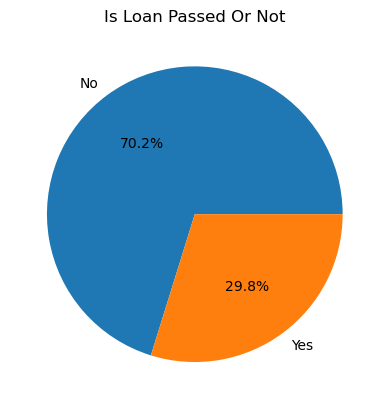

In [201]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan Passed Or Not")

[Text(0, 0, '621'), Text(0, 0, '379')]

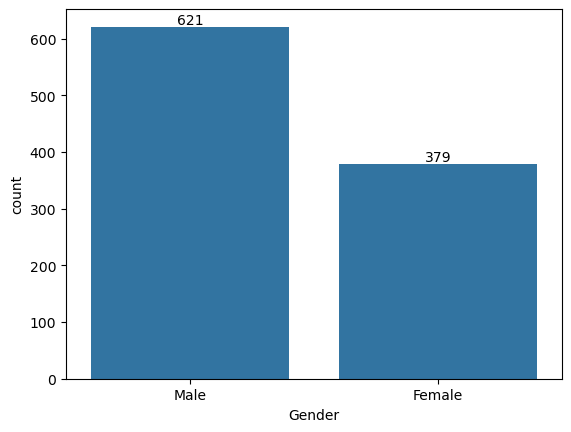

In [202]:
# analyze categories
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

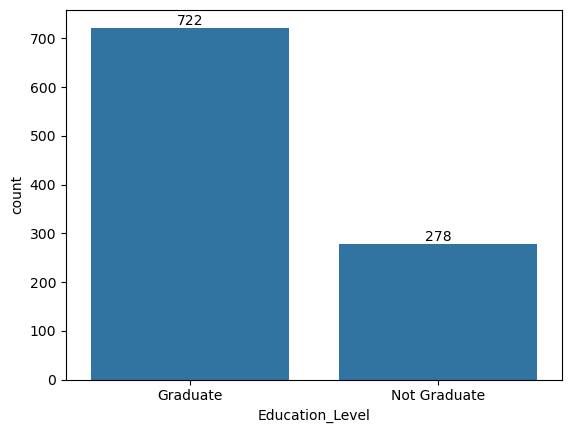

In [203]:
# education category analysis
edu_cnt = df["Education_Level"] .value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

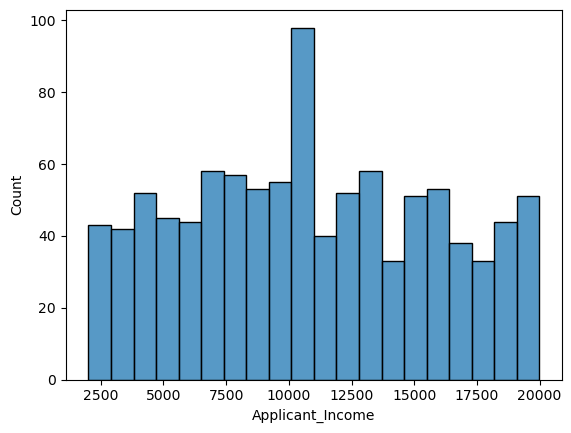

In [204]:
# analyze income
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

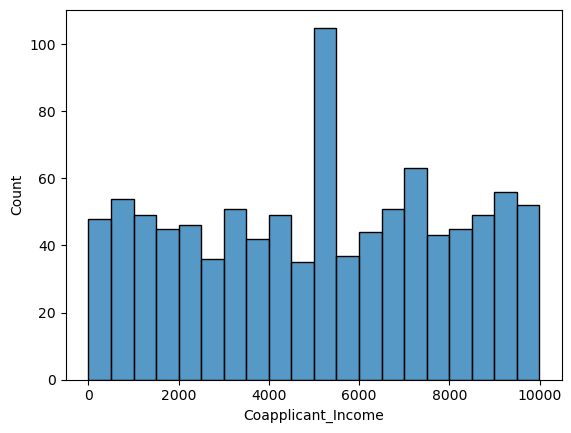

In [205]:
# analyze income of co applicant
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

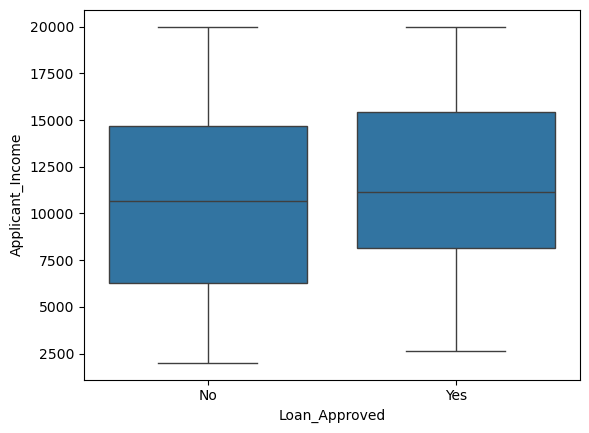

In [206]:
# outliers - box plots

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"

)

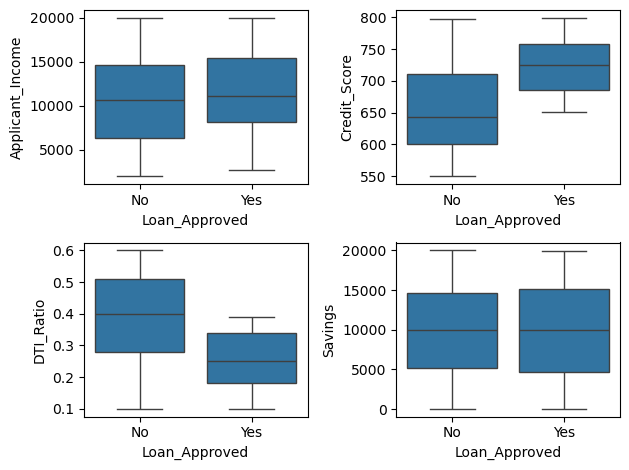

In [207]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Approved", y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

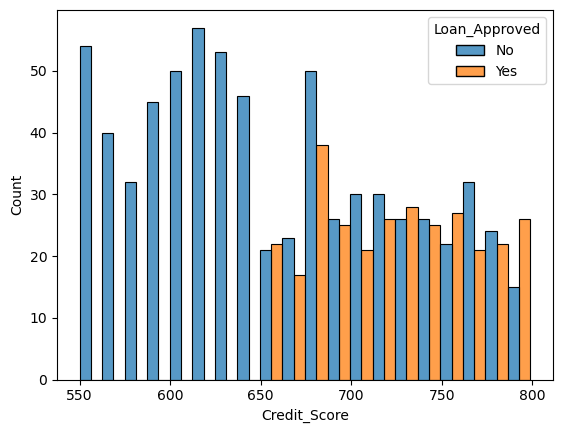

In [208]:
# CREDICT SCORE WITH LOAN APPROVAL CONNECTION 
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple= "dodge"
)

In [209]:
# Remove Applicant Id as it is of no use
df = df.drop("Applicant_ID", axis=1)

df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# FEATURE ENCODING 

In [210]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [211]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# LABEL ENCODING
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

# ONE HOT ENCODER
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose",
        "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# COORELATION HEATMAP

In [213]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

In [214]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

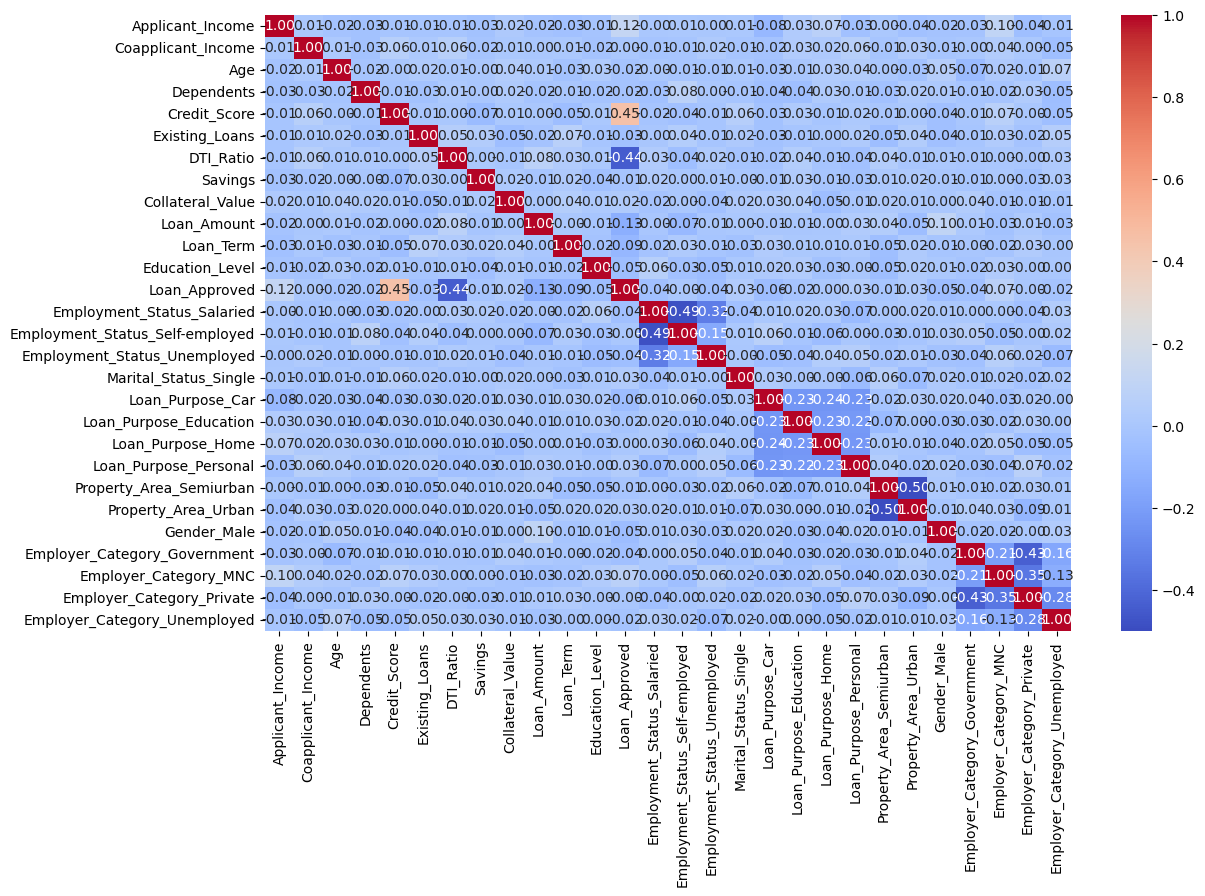

In [215]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(13, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Train Test Split + Feature Scaling

In [216]:
# DIVIDING THE INPUT & OUTPUT 
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [217]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [218]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [219]:
# FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training & Evaluation of Model

In [220]:
# 1. Logistic Reression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# EVALUATION
print("LOGISTIC REGRESSION SCORE :: \n")
print("PRECISION: ", precision_score(y_test, y_pred) * 100, "%")
print("ACCURACY: ", accuracy_score(y_test, y_pred) * 100, "%")
print("F1_SCORE: ", f1_score(y_test, y_pred) * 100, "%")
print("RECALL_SCORE: ", recall_score(y_test, y_pred) * 100, "%")
print("CONFUSION_MATRIX: \n", confusion_matrix(y_test, y_pred))

LOGISTIC REGRESSION SCORE :: 

PRECISION:  78.33333333333333 %
ACCURACY:  86.5 %
F1_SCORE:  77.68595041322314 %
RECALL_SCORE:  77.04918032786885 %
CONFUSION_MATRIX: 
 [[126  13]
 [ 14  47]]


In [221]:
# 2. kNN 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

kNN_model = KNeighborsClassifier(n_neighbors= 5)

kNN_model.fit(X_train_scaled, y_train)

y_pred = kNN_model .predict(X_test_scaled)

# EVALUATION
print("kNN SCORE :: \n")
print("PRECISION: ", precision_score(y_test, y_pred) * 100, "%")
print("ACCURACY: ", accuracy_score(y_test, y_pred) * 100, "%")
print("F1_SCORE: ", f1_score(y_test, y_pred) * 100, "%")
print("RECALL_SCORE: ", recall_score(y_test, y_pred) * 100, "%")
print("CONFUSION_MATRIX: \n", confusion_matrix(y_test, y_pred))

kNN SCORE :: 

PRECISION:  62.745098039215684 %
ACCURACY:  76.0 %
F1_SCORE:  57.14285714285714 %
RECALL_SCORE:  52.459016393442624 %
CONFUSION_MATRIX: 
 [[120  19]
 [ 29  32]]


In [222]:
# 3. Naive Bayes
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Naive_bayes_model = GaussianNB()

Naive_bayes_model.fit(X_train_scaled, y_train)

y_pred = Naive_bayes_model.predict(X_test_scaled)

# EVALUATION
print("NAIVE BAYES SCORE :: \n")
print("PRECISION: ", precision_score(y_test, y_pred) * 100, "%")
print("ACCURACY: ", accuracy_score(y_test, y_pred) * 100, "%")
print("F1_SCORE: ", f1_score(y_test, y_pred) * 100, "%")
print("RECALL_SCORE: ", recall_score(y_test, y_pred) * 100, "%")
print("CONFUSION_MATRIX: \n", confusion_matrix(y_test, y_pred))

NAIVE BAYES SCORE :: 

PRECISION:  80.35714285714286 %
ACCURACY:  86.5 %
F1_SCORE:  76.92307692307693 %
RECALL_SCORE:  73.77049180327869 %
CONFUSION_MATRIX: 
 [[128  11]
 [ 16  45]]


* BEST MODEL ON THE BASIS OF THE PRECISION IS --> NAIVE BAYES MODEL

# FEATURE ENGINEERING 

In [223]:
# Add or Tranform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [224]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187


In [225]:
# 1. Logistic Reression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# EVALUATION
print("LOGISTIC REGRESSION SCORE :: \n")
print("PRECISION: ", precision_score(y_test, y_pred) * 100, "%")
print("ACCURACY: ", accuracy_score(y_test, y_pred) * 100, "%")
print("F1_SCORE: ", f1_score(y_test, y_pred) * 100, "%")
print("RECALL_SCORE: ", recall_score(y_test, y_pred) * 100, "%")
print("CONFUSION_MATRIX: \n", confusion_matrix(y_test, y_pred))

LOGISTIC REGRESSION SCORE :: 

PRECISION:  79.03225806451613 %
ACCURACY:  87.5 %
F1_SCORE:  79.67479674796748 %
RECALL_SCORE:  80.32786885245902 %
CONFUSION_MATRIX: 
 [[126  13]
 [ 12  49]]


In [226]:
# 2. kNN 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

kNN_model = KNeighborsClassifier(n_neighbors= 5)

kNN_model.fit(X_train_scaled, y_train)

y_pred = kNN_model .predict(X_test_scaled)

# EVALUATION
print("kNN SCORE :: \n")
print("PRECISION: ", precision_score(y_test, y_pred) * 100, "%")
print("ACCURACY: ", accuracy_score(y_test, y_pred) * 100, "%")
print("F1_SCORE: ", f1_score(y_test, y_pred) * 100, "%")
print("RECALL_SCORE: ", recall_score(y_test, y_pred) * 100, "%")
print("CONFUSION_MATRIX: \n", confusion_matrix(y_test, y_pred))

kNN SCORE :: 

PRECISION:  62.0 %
ACCURACY:  75.5 %
F1_SCORE:  55.85585585585585 %
RECALL_SCORE:  50.81967213114754 %
CONFUSION_MATRIX: 
 [[120  19]
 [ 30  31]]


In [227]:
# 3. Naive Bayes
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Naive_bayes_model = GaussianNB()

Naive_bayes_model.fit(X_train_scaled, y_train)

y_pred = Naive_bayes_model.predict(X_test_scaled)

# EVALUATION
print("NAIVE BAYES SCORE :: \n")
print("PRECISION: ", precision_score(y_test, y_pred) * 100, "%")
print("ACCURACY: ", accuracy_score(y_test, y_pred) * 100, "%")
print("F1_SCORE: ", f1_score(y_test, y_pred) * 100, "%")
print("RECALL_SCORE: ", recall_score(y_test, y_pred) * 100, "%")
print("CONFUSION_MATRIX: \n", confusion_matrix(y_test, y_pred))

NAIVE BAYES SCORE :: 

PRECISION:  78.33333333333333 %
ACCURACY:  86.5 %
F1_SCORE:  77.68595041322314 %
RECALL_SCORE:  77.04918032786885 %
CONFUSION_MATRIX: 
 [[126  13]
 [ 14  47]]
